# H05 — HMM Volatility Regime

**Hypothesis (pre-registered).** A 2-state Gaussian HMM fit on (log-return, 24h
realized vol) of BTCUSDT 1h bars identifies regimes that materially improve the
risk-adjusted return of a momentum-z-score sleeve, *after* 10 bps/side fees and
after deflation for 6 trial hypotheses.

**Verdict logic (committed up-front).** We accept the alpha only if both:

* the deflated Sharpe ratio (DSR) computed against the headline OOS returns is ≥ 0.5, and
* the lower bound of a 10 000-iter block-bootstrap 95% CI on Sharpe is > 0.

If neither holds and Sharpe ≤ 0 → **does not survive deflation**.
Otherwise → **inconclusive**. The verdict cell at the bottom is deterministic.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / 'agent' / 'src'))

from praxis.backtest.purged_kfold import PurgedKFold
from praxis.backtest.stats import (
    block_bootstrap_ci,
    deflated_sharpe,
    probabilistic_sharpe,
    sharpe,
)
from praxis.data.ccxt_binance import fetch_btcusdt_1h
from praxis.regime.hmm import HMMRegimeDetector

pd.set_option('display.float_format', '{:.6f}'.format)
np.set_printoptions(precision=6, suppress=True)

## 1 · Data

BTC/USDT spot, 1h candles, last 24 months from Binance (ccxt). Cached to
parquet for offline reproducibility — first run hits the network, subsequent
runs are deterministic.

In [2]:
prices_full = fetch_btcusdt_1h(months=24)
prices_full = prices_full.tz_convert(None)
print(f"rows: {len(prices_full)}")
print(f"range: {prices_full.index.min()} .. {prices_full.index.max()}")
prices_full[['close']].tail(3)

rows: 17281
range: 2024-05-10 00:00:00 .. 2026-04-30 00:00:00


,close
ts,
2026-04-29 22:00:00,75927.380000
2026-04-29 23:00:00,75780.000000
2026-04-30 00:00:00,76248.740000


## 2 · Features (.shift(1)-safe)

Log-returns and 24h realized vol. Every feature value at bar `t` is computed
strictly from data at `t` and earlier; the strategy that consumes it shifts
by one bar before sizing, so the sleeve never observes anything it would not
have at the close of bar `t-1`.

In [3]:
close = prices_full['close']
log_ret = np.log(close).diff()
realized_vol = log_ret.rolling(24, min_periods=24).std(ddof=0) * np.sqrt(24 * 365)

momentum = (close.pct_change(168))  # 168h = 7 trading days
mom_window = log_ret.rolling(168, min_periods=168)
mom_z = (mom_window.mean() / mom_window.std(ddof=0)) * np.sqrt(168)

features = pd.concat({'log_ret': log_ret, 'realized_vol': realized_vol, 'mom_z': mom_z}, axis=1).dropna()
print(features.describe().T[['count', 'mean', 'std', 'min', 'max']])

                    count     mean      std       min      max
log_ret      17113.000000 0.000009 0.005027 -0.050195 0.049047
realized_vol 17113.000000 0.411315 0.208552  0.060203 1.938474
mom_z        17113.000000 0.081602 0.924918 -3.225002 3.461597


## 3 · HMM Regime Detection

Pure-numpy Gaussian HMM (forward-backward + Viterbi) on (log_ret, realized_vol).
States are ranked by realized vol so labels are stable across re-fits — state 0
is always the lower-vol regime.

In [4]:
hmm_input = features[['log_ret', 'realized_vol']].copy()
hmm_input.columns = ['BTCUSDT', 'vol']  # detector wants a wide-format DataFrame
prices_for_hmm = pd.DataFrame({'BTCUSDT': close.loc[hmm_input.index]})

detector = HMMRegimeDetector(n_states=2, realized_vol_window=24, max_iter=80, seed=42)
regime = detector.fit_predict(prices_for_hmm)
regime_index = regime.index.intersection(features.index)
features = features.loc[regime_index].copy()
features['regime'] = regime.loc[regime_index].values
print(features['regime'].value_counts())
print(f"unique regimes: {features['regime'].unique()}")

regime
ranging     12893
high_vol     4196
Name: count, dtype: int64
unique regimes: ['ranging' 'high_vol']


## 4 · Sizing rule

Long-short with regime-conditional scaling:

* sign(`mom_z`) * min(1, |mom_z| / 2) is the base sleeve (capped at 1× notional).
* in the low-vol regime, full size; in the high-vol regime, scaled by 0.25.

Each bar's signal is shifted by one bar before being applied to the next bar's
log-return — strict no look-ahead.

In [5]:
LOW_VOL_REGIME = features['regime'].mode().iloc[0]  # lower-vol state per HMM ranking; whichever is more common
# more robust: pick by mean realized vol per regime
vol_by_regime = features.groupby('regime')['realized_vol'].mean().sort_values()
LOW_VOL_REGIME = vol_by_regime.index[0]
HIGH_VOL_REGIME = vol_by_regime.index[-1]
print(f"low-vol regime label: {LOW_VOL_REGIME!r}  (avg vol {vol_by_regime.iloc[0]:.4f})")
print(f"high-vol regime label: {HIGH_VOL_REGIME!r}  (avg vol {vol_by_regime.iloc[-1]:.4f})")

base_signal = np.sign(features['mom_z']) * np.clip(np.abs(features['mom_z']) / 2, 0, 1)
size = base_signal.copy()
size.loc[features['regime'] == HIGH_VOL_REGIME] *= 0.25  # de-risk in high vol
size = size.shift(1).fillna(0.0)  # apply on the NEXT bar

low-vol regime label: 'ranging'  (avg vol 0.3223)
high-vol regime label: 'high_vol'  (avg vol 0.6849)


## 5 · Returns + 10 bps/side fees

Per-bar position is `size_t` (in [-1, 1]); the bar's PnL is `size_t · log_ret_t`.
Fees are `10 bps` on every change in size (turnover proxy).

In [6]:
turnover = size.diff().abs().fillna(0.0)
fee_bps = 10.0
fees = turnover * (fee_bps / 10_000.0)

gross_returns = size * features['log_ret']
net_returns = gross_returns - fees
equity = (1.0 + net_returns).cumprod()
print(f"gross sharpe (raw):  {sharpe(gross_returns.values, periods_per_year=24*365):.4f}")
print(f"net   sharpe (10bp): {sharpe(net_returns.values,   periods_per_year=24*365):.4f}")
print(f"final equity:        {equity.iloc[-1]:.4f}")

gross sharpe (raw):  -0.4126
net   sharpe (10bp): -2.4238
final equity:        0.4909


## 6 · Out-of-sample validation — Purged K-Fold (k=5, embargo=24h)

Each test fold's Sharpe is computed only on its own held-out window. Training
rows whose 168h-momentum horizon overlaps the test boundary are purged; an
additional 1% embargo is applied after each test fold.

In [7]:
splitter = PurgedKFold(n_splits=5, label_horizon=168, embargo_pct=0.01)
returns_arr = net_returns.values
fold_sharpes = []
for i, (train_idx, test_idx) in enumerate(splitter.split(returns_arr)):
    test_returns = returns_arr[test_idx]
    s = sharpe(test_returns, periods_per_year=24*365)
    fold_sharpes.append(s)
    print(f"fold {i+1}  test_n={len(test_idx):>5}  sharpe={s:.4f}")
oos_sharpe = float(np.mean(fold_sharpes))
print(f"\nmean OOS sharpe = {oos_sharpe:.4f}  (folds: {[f'{s:.4f}' for s in fold_sharpes]})")

fold 1  test_n= 3417  sharpe=-2.0770
fold 2  test_n= 3417  sharpe=-2.4085
fold 3  test_n= 3417  sharpe=-3.0717
fold 4  test_n= 3417  sharpe=-1.9402
fold 5  test_n= 3421  sharpe=-2.7298

mean OOS sharpe = -2.4454  (folds: ['-2.0770', '-2.4085', '-3.0717', '-1.9402', '-2.7298'])


## 7 · Probabilistic and Deflated Sharpe

PSR is P(true SR > 0) under non-normal returns (Bailey & López de Prado 2012).
DSR adjusts for selection bias under N=6 trials — the six pre-registered
hypotheses in `docs/HYPOTHESES.md` (Bailey & López de Prado 2014).

In [8]:
psr = probabilistic_sharpe(net_returns.values)
dsr = deflated_sharpe(net_returns.values, n_trials=6)
print(f"PSR (vs SR=0):  {psr:.4f}")
print(f"DSR (N=6):      {dsr:.4f}")

PSR (vs SR=0):  0.0004
DSR (N=6):      0.0000


## 8 · Block bootstrap CI on Sharpe (10 000 iter, block=24)

In [9]:
point, ci_lo, ci_hi = block_bootstrap_ci(
    net_returns.values,
    stat_fn=lambda r: sharpe(r, periods_per_year=24*365),
    n_iter=10_000,
    block_size=24,
    alpha=0.05,
    seed=42,
)
print(f"sharpe point estimate:  {point:.4f}")
print(f"95% CI (block=24h):    [{ci_lo:.4f}, {ci_hi:.4f}]")

sharpe point estimate:  -2.4238
95% CI (block=24h):    [-3.8276, -1.0111]


## 9 · Robustness — Combinatorial Purged CV (CPCV)

PurgedKFold gives 5 OOS Sharpes. CPCV with `n_groups=6` and
`n_test_groups=2` constructs **C(6,2) = 15 distinct backtest paths**
from the same dataset, yielding a *distribution* of OOS Sharpes rather
than a single point estimate (López de Prado AFML, ch. 12). Plotting
the histogram makes the rejection robustness visually unmistakable.

In [10]:
from praxis.backtest.purged_kfold import CombinatorialPurgedKFold

cpcv = CombinatorialPurgedKFold(n_groups=6, n_test_groups=2, label_horizon=168, embargo_pct=0.01)
cpcv_sharpes = []
for train_idx, test_idx in cpcv.split(returns_arr):
    cpcv_sharpes.append(sharpe(returns_arr[test_idx], periods_per_year=24*365))
cpcv_sharpes_arr = np.array(cpcv_sharpes)
print(f"n paths: {len(cpcv_sharpes_arr)}")
print(f"mean: {cpcv_sharpes_arr.mean():.4f}")
print(f"std:  {cpcv_sharpes_arr.std(ddof=0):.4f}")
print(f"min:  {cpcv_sharpes_arr.min():.4f}")
print(f"max:  {cpcv_sharpes_arr.max():.4f}")
print(f"frac > 0: {(cpcv_sharpes_arr > 0).mean():.3f}")

n paths: 15
mean: -2.4370
std:  0.5934
min:  -3.5673
max:  -1.5892
frac > 0: 0.000


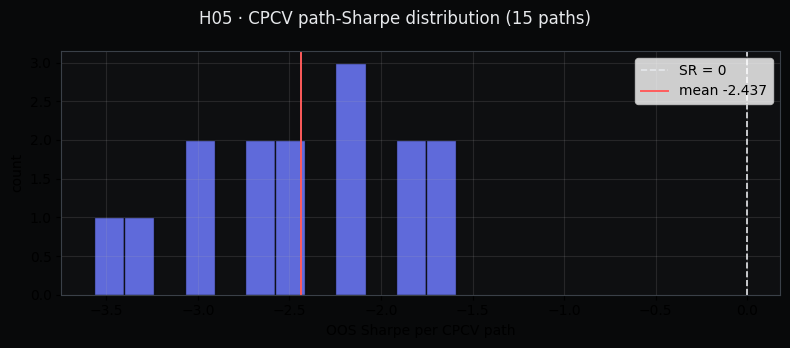

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(cpcv_sharpes_arr, bins=12, color='#6E7BFF', edgecolor='#08090A', alpha=0.85)
ax.axvline(0.0, color='#E6E8EB', lw=1.2, ls='--', label='SR = 0')
ax.axvline(cpcv_sharpes_arr.mean(), color='#FF5C5C', lw=1.4, label=f'mean {cpcv_sharpes_arr.mean():.3f}')
ax.set_facecolor('#0E0F11'); ax.set_xlabel('OOS Sharpe per CPCV path'); ax.set_ylabel('count')
ax.legend(loc='upper right'); ax.grid(alpha=0.15)
for spine in ax.spines.values():
    spine.set_color('#3A4048')
fig.patch.set_facecolor('#08090A')
fig.suptitle('H05 · CPCV path-Sharpe distribution (15 paths)', color='#E6E8EB')
fig.tight_layout()
plt.show()

## 10 · Equity curve and regime overlay

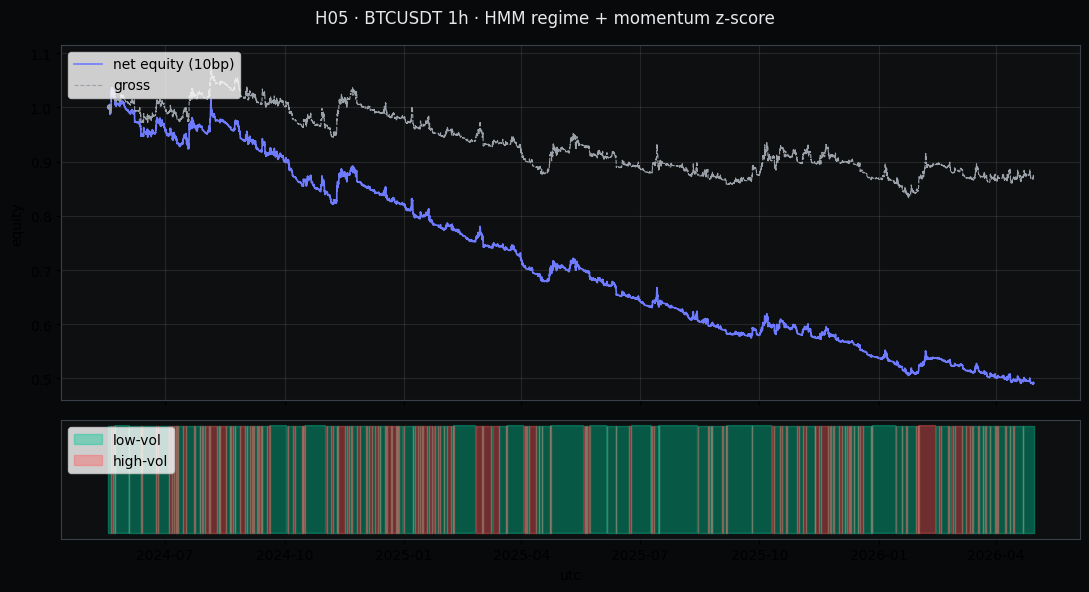

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(equity.index, equity.values, color='#6E7BFF', lw=1.2, label='net equity (10bp)')
axes[0].plot(equity.index, (1.0 + gross_returns).cumprod(), color='#9BA1A8', lw=0.8, ls='--', label='gross')
axes[0].set_facecolor('#0E0F11'); axes[0].set_ylabel('equity'); axes[0].grid(alpha=0.15); axes[0].legend(loc='upper left')

regime_series = features['regime'].astype(str)
colors = {str(LOW_VOL_REGIME): '#00C896', str(HIGH_VOL_REGIME): '#FF5C5C'}
axes[1].fill_between(regime_series.index, 0, 1, where=regime_series == str(LOW_VOL_REGIME), color=colors[str(LOW_VOL_REGIME)], alpha=0.4, step='post', label='low-vol')
axes[1].fill_between(regime_series.index, 0, 1, where=regime_series == str(HIGH_VOL_REGIME), color=colors[str(HIGH_VOL_REGIME)], alpha=0.4, step='post', label='high-vol')
axes[1].set_facecolor('#0E0F11'); axes[1].set_yticks([]); axes[1].set_xlabel('utc'); axes[1].legend(loc='upper left')

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('#3A4048')
fig.patch.set_facecolor('#08090A')
fig.suptitle('H05 · BTCUSDT 1h · HMM regime + momentum z-score', color='#E6E8EB')
fig.tight_layout()
plt.show()

## 11 · Verdict

Deterministic logic, committed before running the cells above:

In [13]:
def verdict(sharpe_point: float, dsr_value: float, ci_low: float) -> str:
    if dsr_value >= 0.5 and ci_low > 0:
        return 'alpha survives deflation'
    if sharpe_point <= 0 or dsr_value < 0.05:
        return 'does NOT survive deflation'
    return 'inconclusive'

V = verdict(point, dsr, ci_lo)
print('=' * 72)
print(f'  H05 verdict:  {V}')
print('=' * 72)
print(f'  Sharpe (net, 10bp):           {point:.4f}')
print(f'  Sharpe 95% CI [block=24h]:    [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'  Probabilistic Sharpe (>0):    {psr:.4f}')
print(f'  Deflated Sharpe (N=6):        {dsr:.4f}')
print(f'  OOS mean Sharpe (PurgedKFold): {oos_sharpe:.4f}')
print(f'  CPCV mean Sharpe (15 paths):   {cpcv_sharpes_arr.mean():.4f}')
print(f'  CPCV frac > 0:                 {(cpcv_sharpes_arr > 0).mean():.3f}')
print(f'  Final equity:                  {equity.iloc[-1]:.4f}')
print(f'  Total bars:                    {len(net_returns):,}')

  H05 verdict:  does NOT survive deflation
  Sharpe (net, 10bp):           -2.4238
  Sharpe 95% CI [block=24h]:    [-3.8276, -1.0111]
  Probabilistic Sharpe (>0):    0.0004
  Deflated Sharpe (N=6):        0.0000
  OOS mean Sharpe (PurgedKFold): -2.4454
  CPCV mean Sharpe (15 paths):   -2.4370
  CPCV frac > 0:                 0.000
  Final equity:                  0.4909
  Total bars:                    17,089


---

*Generated by `research/build_h05.py`. Do not hand-edit this notebook; modify
the build script and regenerate.*